# Pam Rock Data 

## Observation Data Download

In [1]:
# Downloading

import os
import requests
import re
import time

def download_climate_data():
    # 参数设置
    station_id = 6817       # for pam rocks, id=6817
    start_year = 2023       
    end_year = 2023
    
    # 目标保存路径
    save_dir = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_obs/Data_Pam_Rock_2023"
    
    # 如果目录不存在，则创建它
    os.makedirs(save_dir, exist_ok=True)
    print(f"开始下载数据，保存至: {save_dir}")

    # 循环年份和月份
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            # 构造下载链接 (timeframe=1 表示逐时数据)
            url = (
                f"https://climate.weather.gc.ca/climate_data/bulk_data_e.html?"
                f"format=csv&time=UTC&stationID={station_id}&Year={year}&Month={month}"
                f"&Day=14&timeframe=1&submit=Download+Data"
            )
            
            try:
                # 发送 GET 请求
                response = requests.get(url, timeout=30)
                response.raise_for_status() # 检查是否有 4xx/5xx 错误
                
                # 尝试从 Header 中获取官方提供的文件名 (类似 wget --content-disposition)
                content_disposition = response.headers.get('content-disposition')
                if content_disposition:
                    # 使用正则提取 filename="xxx.csv" 中的文件名
                    fname_match = re.findall('filename="?([^"]+)"?', content_disposition)
                    if fname_match:
                        filename = fname_match[0]
                    else:
                        filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                else:
                    filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                    
                filepath = os.path.join(save_dir, filename)
                
                # 将内容写入本地文件
                with open(filepath, 'wb') as f:
                    f.write(response.content)
                    
                print(f"成功下载: {filename}")
                
                # 暂停 1 秒，避免请求过于频繁导致被加拿大环境部服务器封禁 IP
                time.sleep(1) 

            except requests.exceptions.RequestException as e:
                print(f"下载失败 {year}年{month:02d}月: {e}")

    print("所有数据下载完成！")

if __name__ == "__main__":
    download_climate_data()

开始下载数据，保存至: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_obs/Data_Pam_Rock_2023
下载失败 2023年01月: HTTPSConnectionPool(host='climate.weather.gc.ca', port=443): Max retries exceeded with url: /climate_data/bulk_data_e.html?format=csv&time=UTC&stationID=6817&Year=2023&Month=1&Day=14&timeframe=1&submit=Download+Data (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x7faee5ec9fd0>, 'Connection to climate.weather.gc.ca timed out. (connect timeout=30)'))
成功下载: en_climate_hourly_BC_10459NN_02-2023_P1H.csv
成功下载: en_climate_hourly_BC_10459NN_03-2023_P1H.csv
成功下载: en_climate_hourly_BC_10459NN_04-2023_P1H.csv
下载失败 2023年05月: HTTPSConnectionPool(host='climate.weather.gc.ca', port=443): Max retries exceeded with url: /climate_data/bulk_data_e.html?format=csv&time=UTC&stationID=6817&Year=2023&Month=5&Day=14&timeframe=1&submit=Download+Data (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at

## CaSR Data Extraction

Recall that: 

```
====================================================================================================
Pam Rocks
NEMO target: y=502, x=341
====================================================================================================

********** 4 atmospheric points actually USED **********

source 2: (ilat, ilon)=(  57,   36)   lat= 49.402325   lon= 236.736679   weight=0.0239716401
source 4: (ilat, ilon)=(  57,   37)   lat= 49.441509   lon= 236.860794   weight=0.0047739371
source 1: (ilat, ilon)=(  58,   36)   lat= 49.483242   lon= 236.676086   weight=0.8099528243
source 3: (ilat, ilon)=(  58,   37)   lat= 49.522491   lon= 236.800385   weight=0.1613015984

********** Neighboring atmospheric grid points (deduplicated) **********

(ilat, ilon)=(  56,   35)   lat= 49.282116   lon= 236.673340   neighbor_of=[2]
(ilat, ilon)=(  56,   36)   lat= 49.321369   lon= 236.797089   neighbor_of=[2, 4]
(ilat, ilon)=(  56,   37)   lat= 49.360485   lon= 236.921021   neighbor_of=[2, 4]
(ilat, ilon)=(  56,   38)   lat= 49.399456   lon= 237.045181   neighbor_of=[4]
(ilat, ilon)=(  57,   35)   lat= 49.363010   lon= 236.612778   neighbor_of=[1, 2]
(ilat, ilon)=(  57,   38)   lat= 49.480549   lon= 236.985138   neighbor_of=[3, 4]
(ilat, ilon)=(  58,   35)   lat= 49.443859   lon= 236.552017   neighbor_of=[1, 2]
(ilat, ilon)=(  58,   38)   lat= 49.561611   lon= 236.924896   neighbor_of=[3, 4]
(ilat, ilon)=(  59,   35)   lat= 49.524673   lon= 236.491058   neighbor_of=[1]
(ilat, ilon)=(  59,   36)   lat= 49.564133   lon= 236.615295   neighbor_of=[1, 3]
(ilat, ilon)=(  59,   37)   lat= 49.603451   lon= 236.739761   neighbor_of=[1, 3]
(ilat, ilon)=(  59,   38)   lat= 49.642628   lon= 236.864441   neighbor_of=[3]

----------------------------------------------------------------------------------------------------
Number of USED points     = 4
Number of unique neighbors = 12
Total plotted points       = 16
Sum of interpolation weights = 1.000000000000
```

in https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights/Fjords.ipynb

The 'reliable' grid point lies in the South, which is `(ilat, ilon)=(  56,   35)   lat= 49.282116   lon= 236.673340   neighbor_of=[2]`. The nearest grid point to Pam Rocks in CaSR is `source 1: (ilat, ilon)=(  58,   36)   lat= 49.483242   lon= 236.676086   weight=0.8099528243`.



In [ ]:
# ============================================================
# Extract CaSR tair at two Pam Rocks grid points for all of 2023
#
# 1. nearest_ocean:
#    (ilat, ilon) = (56, 35)
#    lat = 49.282116
#    lon = 236.673340
#
# 2. nearest_point:
#    (ilat, ilon) = (58, 36)
#    lat = 49.483242
#    lon = 236.676086
#
# Output:
# time_counter | CaSR_nearest_ocean_C | CaSR_nearest_point_C
# ============================================================

import xarray as xr
import pandas as pd
from pathlib import Path
import glob


# ============================================================
# 1. Paths
# ============================================================

casr_dir = Path(
    "/ocean/jqiu/forcings/CaSR"
)

output_dir = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_CaSR"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. All CaSR files in 2023
# ============================================================

casr_files = sorted(
    glob.glob(
        str(casr_dir / "CaSR_y2023m*d*.nc")
    )
)

print(f"CaSR 2023 files: {len(casr_files)}")

if len(casr_files) == 0:
    raise FileNotFoundError(
        f"No CaSR 2023 files found in {casr_dir}"
    )


# ============================================================
# 3. Two Pam Rocks grid points
#
# y = ilat
# x = ilon
# ============================================================

pamrocks_points = {
    "nearest_ocean": {
        "y": 56,
        "x": 35,
        "expected_lat": 49.282116,
        "expected_lon": 236.673340,
    },

    "nearest_point": {
        "y": 58,
        "x": 36,
        "expected_lat": 49.483242,
        "expected_lon": 236.676086,
    },
}


# ============================================================
# 4. Open CaSR
# ============================================================

ds = xr.open_mfdataset(
    casr_files,
    combine="by_coords",
    parallel=True,
    chunks={"time_counter": 24},
)


# ============================================================
# 5. Convert tair to Celsius
# ============================================================

def temperature_to_celsius(da):

    units = str(
        da.attrs.get("units", "")
    ).strip().lower()

    print(
        f"tair units from file: "
        f"{da.attrs.get('units', 'unknown')}"
    )

    if units in [
        "k",
        "kelvin",
        "degrees_k",
        "degree_k",
    ]:
        return da - 273.15

    elif units in [
        "c",
        "degc",
        "degree_celsius",
        "degrees_celsius",
        "celsius",
    ]:
        return da

    else:
        sample = float(
            da.isel(
                time_counter=0,
                y=0,
                x=0,
            ).values
        )

        if sample > 100:
            print(
                "WARNING: tair units not identified; "
                "values look like Kelvin. "
                "Converting to Celsius."
            )
            return da - 273.15

        else:
            print(
                "WARNING: tair units not identified; "
                "assuming Celsius."
            )
            return da


tair_C = temperature_to_celsius(ds["tair"])


# ============================================================
# 6. Extract the two points
# ============================================================

series = {}

for point_name, p in pamrocks_points.items():

    y_idx = p["y"]
    x_idx = p["x"]

    # Actual grid coordinates from file
    grid_lat = float(
        ds["nav_lat"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    grid_lon = float(
        ds["nav_lon"].isel(
            y=y_idx,
            x=x_idx,
        ).values
    )

    grid_lon_180 = (
        grid_lon - 360
        if grid_lon > 180
        else grid_lon
    )

    print(
        "\n"
        "===================================================="
    )
    print(f"{point_name}")
    print(
        "===================================================="
    )

    print(
        f"(ilat, ilon)=({y_idx}, {x_idx})"
    )

    print(
        f"grid lat = {grid_lat:.6f}"
    )

    print(
        f"grid lon = {grid_lon:.6f} "
        f"({grid_lon_180:.6f} in -180~180)"
    )

    print(
        f"expected lat/lon = "
        f"{p['expected_lat']:.6f}, "
        f"{p['expected_lon']:.6f}"
    )

    # Extract entire 2023 time series
    da = tair_C.isel(
        y=y_idx,
        x=x_idx,
    )

    df = (
        da
        .to_dataframe(
            name=f"CaSR_{point_name}_C"
        )
        .reset_index()
    )

    # Keep only time + temperature
    df = df[
        [
            "time_counter",
            f"CaSR_{point_name}_C",
        ]
    ]

    series[point_name] = df


# ============================================================
# 7. Put the two series side by side
# ============================================================

df_out = series["nearest_ocean"].merge(
    series["nearest_point"],
    on="time_counter",
    how="outer",
)

df_out = (
    df_out
    .sort_values("time_counter")
    .reset_index(drop=True)
)


# ============================================================
# 8. Difference between the two CaSR points
#
# positive:
# nearest point is warmer than nearest ocean point
# ============================================================

df_out["CaSR_point_minus_ocean_C"] = (
    df_out["CaSR_nearest_point_C"]
    - df_out["CaSR_nearest_ocean_C"]
)


# ============================================================
# 9. Save
# ============================================================

output_file = (
    output_dir /
    "CaSR_PamRocks_two_gridpoints_tair_2023.csv"
)

df_out.to_csv(
    output_file,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S",
)


# ============================================================
# 10. Close dataset
# ============================================================

ds.close()

print("\nAll done.")

## CaSR Visualization

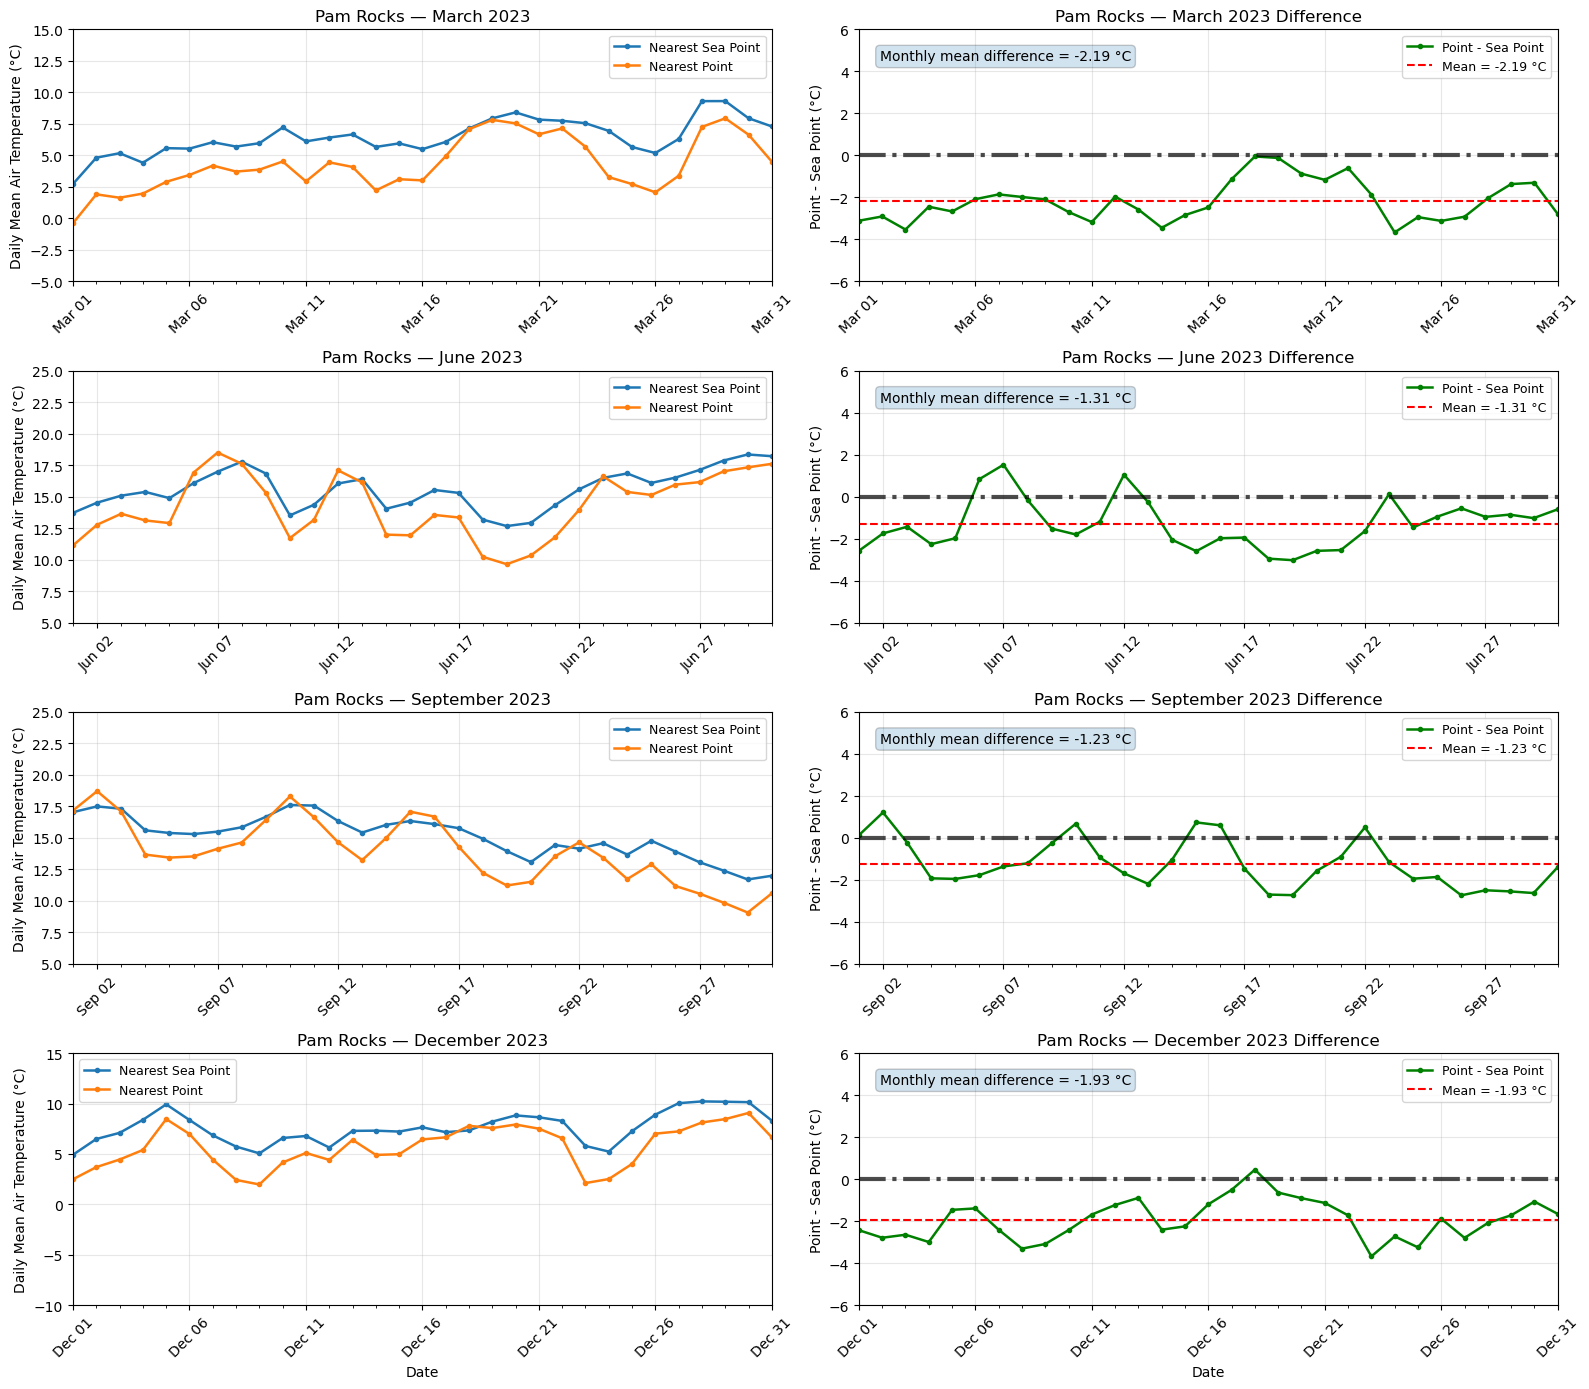

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. File path
# ============================================================

path_casr = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_CaSR/"
    "CaSR_PamRocks_tair_2023.csv"
)


# ============================================================
# 2. Read data
# ============================================================

df = pd.read_csv(path_casr)

df["time_counter"] = pd.to_datetime(
    df["time_counter"]
)

df = df.set_index("time_counter")

df = df.sort_index()


# ============================================================
# 3. Column names
# ============================================================

ocean_col = "CaSR_nearest_ocean_C"

point_col = "CaSR_nearest_point_C"

diff_col = "CaSR_point_minus_ocean_C"


# ============================================================
# 4. Calculate daily mean
# ============================================================

daily = df[
    [
        ocean_col,
        point_col,
        diff_col,
    ]
].resample("1D").mean()


# ============================================================
# 5. Manually define four months
# ============================================================

periods = [
    (
        "March 2023",
        pd.Timestamp("2023-03-01"),
        pd.Timestamp("2023-03-31"),
    ),
    (
        "June 2023",
        pd.Timestamp("2023-06-01"),
        pd.Timestamp("2023-06-30"),
    ),
    (
        "September 2023",
        pd.Timestamp("2023-09-01"),
        pd.Timestamp("2023-09-30"),
    ),
    (
        "December 2023",
        pd.Timestamp("2023-12-01"),
        pd.Timestamp("2023-12-31"),
    ),
]


# ============================================================
# 6. Plot
#
#    Rows:
#        March
#        June
#        September
#        December
#
#    Left column:
#        Nearest Sea Point
#        Nearest Point
#
#    Right column:
#        Point - Sea Point
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 14),
)


# ============================================================
# 7. Loop through months
# ============================================================

for row, (period_title, start_time, end_time) in enumerate(periods):

    # --------------------------------------------------------
    # Select current month
    # --------------------------------------------------------

    month_data = daily.loc[
        start_time:end_time
    ]


    # ========================================================
    # LEFT COLUMN:
    # Nearest Sea Point vs Nearest Point
    # ========================================================

    ax = axes[row, 0]


    # --------------------------------------------------------
    # Nearest Sea Point
    # --------------------------------------------------------

    ax.plot(
        month_data.index,
        month_data[ocean_col],
        linewidth=1.8,
        marker="o",
        markersize=3,
        label="Nearest Sea Point",
    )


    # --------------------------------------------------------
    # Nearest Point
    # --------------------------------------------------------

    ax.plot(
        month_data.index,
        month_data[point_col],
        linewidth=1.8,
        marker="o",
        markersize=3,
        label="Nearest Point",
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        f"Pam Rocks — {period_title}",
        fontsize=12,
    )

    ax.set_ylabel(
        "Daily Mean Air Temperature (°C)"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="best",
        fontsize=9,
    )


    # --------------------------------------------------------
    # Manual temperature ranges
    # --------------------------------------------------------

    if period_title == "March 2023":

        ax.set_ylim(
            -5,
            15,
        )

    elif period_title == "June 2023":

        ax.set_ylim(
            5,
            25,
        )

    elif period_title == "September 2023":

        ax.set_ylim(
            5,
            25,
        )

    elif period_title == "December 2023":

        ax.set_ylim(
            -10,
            15,
        )


    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    ax.set_xlim(
        start_time,
        end_time,
    )

    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=5)
    )

    ax.xaxis.set_minor_locator(
        mdates.DayLocator(interval=1)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %d")
    )

    ax.tick_params(
        axis="x",
        rotation=45,
    )


    # ========================================================
    # RIGHT COLUMN:
    # Point - Sea Point
    # ========================================================

    ax_diff = axes[row, 1]


    # --------------------------------------------------------
    # Daily difference
    # --------------------------------------------------------

    ax_diff.plot(
        month_data.index,
        month_data[diff_col],
        linewidth=1.8,
        marker="o",
        markersize=3,
        color="g",
        label="Point - Sea Point",
    )


    # --------------------------------------------------------
    # Calculate monthly mean difference
    # --------------------------------------------------------

    mean_diff = month_data[diff_col].mean()


    # --------------------------------------------------------
    # Plot monthly mean difference
    # --------------------------------------------------------

    ax_diff.axhline(
        y=mean_diff,
        color="r",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {mean_diff:.2f} °C",
    )


    # --------------------------------------------------------
    # Zero line
    # --------------------------------------------------------

    ax_diff.axhline(
        y=0,
        color="k",
        linestyle="-.",
        linewidth=3.0,
        alpha=0.7,
    )


    # --------------------------------------------------------
    # Write mean difference directly on figure
    # --------------------------------------------------------

    ax_diff.text(
        0.03,
        0.92,
        f"Monthly mean difference = {mean_diff:.2f} °C",
        transform=ax_diff.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            alpha=0.3,
        ),
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax_diff.set_title(
        f"Pam Rocks — {period_title} Difference",
        fontsize=12,
    )

    ax_diff.set_ylabel(
        "Point - Sea Point (°C)"
    )

    ax_diff.grid(
        True,
        alpha=0.3,
    )

    ax_diff.legend(
        loc="best",
        fontsize=9,
    )


    # --------------------------------------------------------
    # Manual difference range
    # --------------------------------------------------------

    ax_diff.set_ylim(
        -6,
        6,
    )


    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    ax_diff.set_xlim(
        start_time,
        end_time,
    )

    ax_diff.xaxis.set_major_locator(
        mdates.DayLocator(interval=5)
    )

    ax_diff.xaxis.set_minor_locator(
        mdates.DayLocator(interval=1)
    )

    ax_diff.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %d")
    )

    ax_diff.tick_params(
        axis="x",
        rotation=45,
    )


# ============================================================
# 8. X labels
# ============================================================

axes[-1, 0].set_xlabel(
    "Date"
)

axes[-1, 1].set_xlabel(
    "Date"
)




# ============================================================
# 10. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 11. Show
# ============================================================

plt.show()





## Obs vs CaSR

In [ ]:
import pandas as pd

path_casr='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_CaSR/CaSR_PamRocks_tair_2023.csv'

path_obs_mar='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_obs/Data_Pam_Rock_2023/en_climate_hourly_BC_10459NN_03-2023_P1H.csv'

path_obs_jun='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_obs/Data_Pam_Rock_2023/en_climate_hourly_BC_10459NN_06-2023_P1H.csv'

path_obs_dec='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_obs/Data_Pam_Rock_2023/en_climate_hourly_BC_10459NN_12-2023_P1H.csv'

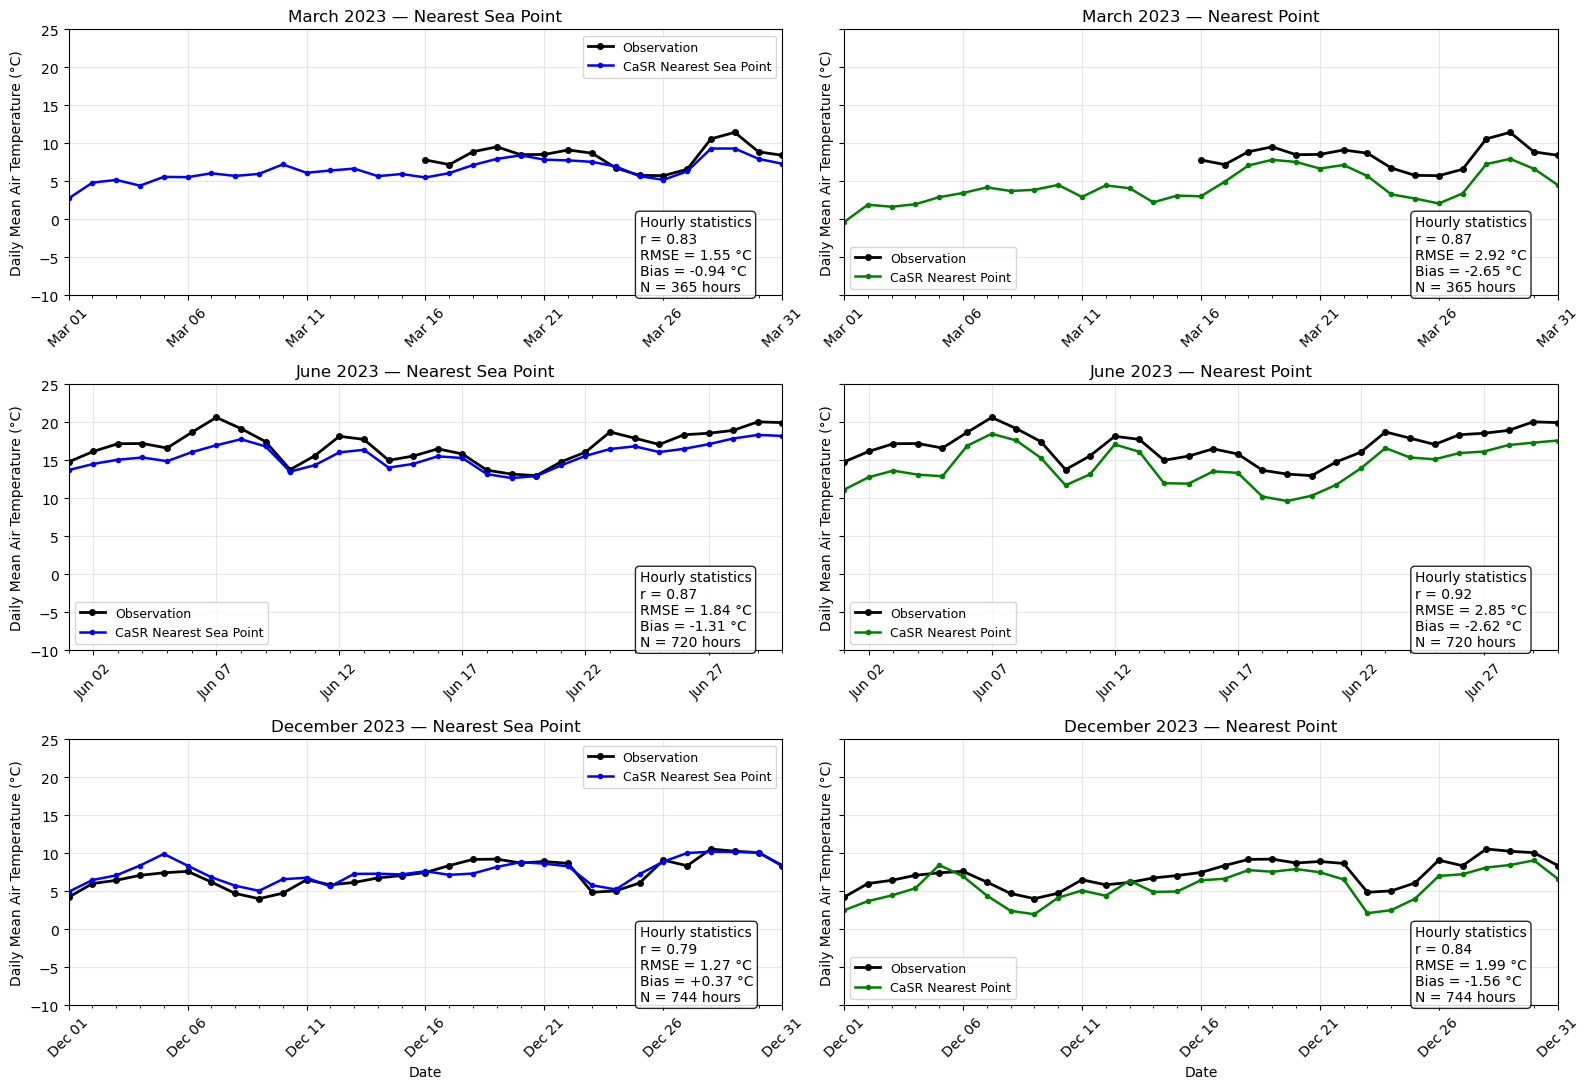

In [ ]:
# visualize
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np


# ============================================================
# 1. File paths
# ============================================================

path_casr = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_CaSR/"
    "CaSR_PamRocks_tair_2023.csv"
)

path_obs_mar = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_obs/"
    "Data_Pam_Rock_2023/"
    "en_climate_hourly_BC_10459NN_03-2023_P1H.csv"
)

path_obs_jun = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_obs/"
    "Data_Pam_Rock_2023/"
    "en_climate_hourly_BC_10459NN_06-2023_P1H.csv"
)

path_obs_dec = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_obs/"
    "Data_Pam_Rock_2023/"
    "en_climate_hourly_BC_10459NN_12-2023_P1H.csv"
)


# ============================================================
# 2. Read CaSR hourly data
# ============================================================

casr = pd.read_csv(path_casr)

casr["time_counter"] = pd.to_datetime(
    casr["time_counter"]
)

casr = casr.set_index("time_counter")

casr = casr.sort_index()


# ============================================================
# 3. CaSR columns
# ============================================================

ocean_col = "CaSR_nearest_ocean_C"

point_col = "CaSR_nearest_point_C"


# ============================================================
# 4. Make sure model values are numeric
# ============================================================

casr[ocean_col] = pd.to_numeric(
    casr[ocean_col],
    errors="coerce",
)

casr[point_col] = pd.to_numeric(
    casr[point_col],
    errors="coerce",
)


# ============================================================
# 5. Daily CaSR data for plotting
# ============================================================

casr_daily = casr[
    [
        ocean_col,
        point_col,
    ]
].resample("1D").mean()


# ============================================================
# 6. Function to read observation hourly data
# ============================================================

def read_obs(path):

    df = pd.read_csv(path)

    df["Date/Time (UTC)"] = pd.to_datetime(
        df["Date/Time (UTC)"]
    )

    df["Temp (°C)"] = pd.to_numeric(
        df["Temp (°C)"],
        errors="coerce",
    )

    df = df.set_index(
        "Date/Time (UTC)"
    )

    df = df.sort_index()

    return df["Temp (°C)"]


# ============================================================
# 7. Read hourly observations
# ============================================================

obs_mar_hourly = read_obs(path_obs_mar)

obs_jun_hourly = read_obs(path_obs_jun)

obs_dec_hourly = read_obs(path_obs_dec)


# ============================================================
# 8. Daily observations for plotting
# ============================================================

obs_mar_daily = obs_mar_hourly.resample(
    "1D"
).mean()

obs_jun_daily = obs_jun_hourly.resample(
    "1D"
).mean()

obs_dec_daily = obs_dec_hourly.resample(
    "1D"
).mean()


# ============================================================
# 9. Define months
# ============================================================

periods = [
    (
        "March 2023",
        pd.Timestamp("2023-03-01"),
        pd.Timestamp("2023-03-31 23:59"),
        obs_mar_hourly,
        obs_mar_daily,
    ),
    (
        "June 2023",
        pd.Timestamp("2023-06-01"),
        pd.Timestamp("2023-06-30 23:59"),
        obs_jun_hourly,
        obs_jun_daily,
    ),
    (
        "December 2023",
        pd.Timestamp("2023-12-01"),
        pd.Timestamp("2023-12-31 23:59"),
        obs_dec_hourly,
        obs_dec_daily,
    ),
]


# ============================================================
# 10. Calculate hourly statistics
#
#     Statistics:
#       Pearson correlation coefficient
#       RMSE
#       Mean Bias
#
#     Only timestamps where BOTH observation and model
#     are available are used.
# ============================================================

def calculate_statistics(obs, model):

    compare = pd.concat(
        [
            obs.rename("OBS"),
            model.rename("MODEL"),
        ],
        axis=1,
    )

    compare = compare.dropna()

    if len(compare) < 2:

        return np.nan, np.nan, np.nan, 0

    # Pearson correlation
    r = compare["OBS"].corr(
        compare["MODEL"]
    )

    # RMSE
    rmse = np.sqrt(
        np.mean(
            (
                compare["MODEL"]
                - compare["OBS"]
            ) ** 2
        )
    )

    # Mean bias: Model - Observation
    bias = np.mean(
        compare["MODEL"]
        - compare["OBS"]
    )

    return r, rmse, bias, len(compare)


# ============================================================
# 11. Plot
#
#     Rows:
#       March
#       June
#       December
#
#     Left:
#       OBS vs CaSR nearest sea point
#
#     Right:
#       OBS vs CaSR nearest point
#
#     Lines:
#       Daily mean
#
#     Statistics:
#       Hourly
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 11),
    sharey=True,
)


# ============================================================
# 12. Loop through months
# ============================================================

for row, (
    month_title,
    start_time,
    end_time,
    obs_hourly,
    obs_daily,
) in enumerate(periods):


    # --------------------------------------------------------
    # Hourly CaSR for statistics
    # --------------------------------------------------------

    casr_hourly_month = casr.loc[
        start_time:end_time
    ]


    # --------------------------------------------------------
    # Daily CaSR for plotting
    # --------------------------------------------------------

    casr_daily_month = casr_daily.loc[
        start_time:end_time
    ]


    # --------------------------------------------------------
    # Current month's hourly observation
    # --------------------------------------------------------

    obs_hourly_month = obs_hourly.loc[
        start_time:end_time
    ]


    # --------------------------------------------------------
    # Current month's daily observation
    # --------------------------------------------------------

    obs_daily_month = obs_daily.loc[
        start_time:end_time
    ]


    # ========================================================
    # LEFT:
    # Nearest Sea Point
    # ========================================================

    ax = axes[row, 0]


    # --------------------------------------------------------
    # HOURLY statistics
    # --------------------------------------------------------

    r_ocean, rmse_ocean, bias_ocean, n_ocean = (
        calculate_statistics(
            obs_hourly_month,
            casr_hourly_month[ocean_col],
        )
    )


    # --------------------------------------------------------
    # Plot DAILY observation
    # --------------------------------------------------------

    ax.plot(
        obs_daily_month.index,
        obs_daily_month.values,
        linewidth=2.0,
        marker="o",
        markersize=4,
        color="k",
        label="Observation",
    )


    # --------------------------------------------------------
    # Plot DAILY CaSR sea point
    # --------------------------------------------------------

    ax.plot(
        casr_daily_month.index,
        casr_daily_month[ocean_col],
        linewidth=1.8,
        marker="o",
        markersize=3,
        color="b",
        label="CaSR Nearest Sea Point",
    )


    # --------------------------------------------------------
    # Statistics text
    # --------------------------------------------------------

    ax.text(
        0.8,
        0.35,
        (
            f"Hourly statistics\n"
            f"r = {r_ocean:.2f}\n"
            f"RMSE = {rmse_ocean:.2f} °C\n"
            f"Bias = {bias_ocean:+.2f} °C\n"
            f"N = {n_ocean} hours"
        ),
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
        ),
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        f"{month_title} — Nearest Sea Point",
        fontsize=12,
    )

    ax.set_ylabel(
        "Daily Mean Air Temperature (°C)"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="best",
        fontsize=9,
    )

    ax.set_xlim(
        start_time.normalize(),
        end_time.normalize(),
    )


    # ========================================================
    # RIGHT:
    # Nearest Point
    # ========================================================

    ax = axes[row, 1]


    # --------------------------------------------------------
    # HOURLY statistics
    # --------------------------------------------------------

    r_point, rmse_point, bias_point, n_point = (
        calculate_statistics(
            obs_hourly_month,
            casr_hourly_month[point_col],
        )
    )


    # --------------------------------------------------------
    # Plot DAILY observation
    # --------------------------------------------------------

    ax.plot(
        obs_daily_month.index,
        obs_daily_month.values,
        linewidth=2.0,
        marker="o",
        markersize=4,
        color="k",
        label="Observation",
    )


    # --------------------------------------------------------
    # Plot DAILY nearest point
    # --------------------------------------------------------

    ax.plot(
        casr_daily_month.index,
        casr_daily_month[point_col],
        linewidth=1.8,
        marker="o",
        markersize=3,
        color="g",
        label="CaSR Nearest Point",
    )


    # --------------------------------------------------------
    # Statistics text
    # --------------------------------------------------------

    ax.text(
        0.8,
        0.35,
        (
            f"Hourly statistics\n"
            f"r = {r_point:.2f}\n"
            f"RMSE = {rmse_point:.2f} °C\n"
            f"Bias = {bias_point:+.2f} °C\n"
            f"N = {n_point} hours"
        ),
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
        ),
    )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        f"{month_title} — Nearest Point",
        fontsize=12,
    )

    ax.set_ylabel(
        "Daily Mean Air Temperature (°C)"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="lower left",
        fontsize=9,
    )

    ax.set_xlim(
        start_time.normalize(),
        end_time.normalize(),
    )


    # ========================================================
    # X-axis formatting
    # ========================================================

    for col in range(2):

        ax_temp = axes[row, col]

        ax_temp.xaxis.set_major_locator(
            mdates.DayLocator(interval=5)
        )

        ax_temp.xaxis.set_minor_locator(
            mdates.DayLocator(interval=1)
        )

        ax_temp.xaxis.set_major_formatter(
            mdates.DateFormatter("%b %d")
        )

        ax_temp.tick_params(
            axis="x",
            rotation=45,
        )


# ============================================================
# 13. Common y-axis range
# ============================================================

for ax in axes.flat:

    ax.set_ylim(
        -10,
        25,
    )


# ============================================================
# 14. X labels
# ============================================================

axes[-1, 0].set_xlabel(
    "Date"
)

axes[-1, 1].set_xlabel(
    "Date"
)



# ============================================================
# 16. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 17. Show
# ============================================================

plt.show()
